## Setup

In [1]:
!pip install -q ultralytics easyocr

import torch, ultralytics, gc
ultralytics.checks()
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"Total VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

def mem_check(tag=""):
    """Quick RAM/VRAM watchdog — call this anytime you're unsure how much headroom is left."""
    import psutil
    ram = psutil.virtual_memory()
    print(f"[{tag}] RAM: {ram.used/1e9:.2f}/{ram.total/1e9:.2f} GB", end="  ")
    if torch.cuda.is_available():
        print(f"| GPU: {torch.cuda.memory_allocated()/1e9:.2f}/{torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB")
    else:
        print()

def free_mem():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

mem_check("startup")

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.4/112.6 GB disk)
GPU available: True
GPU: Tesla T4
Total VRAM: 15.6 GB
[startup] RAM: 1.34/13.61 GB  | GPU: 0.00/15.64 GB


## Download the dataset from Roboflow

In [3]:
!pip install -q roboflow

from roboflow import Roboflow
from getpass import getpass

api_key = getpass("API Key: ")
rf = Roboflow(api_key=api_key)
project = rf.workspace("roboflow-universe-projects").project("license-plate-recognition-rxg4e")
version = project.version(13)

dataset_zip_dir = version.download("yolov8", location="/content/lp_dataset_raw", overwrite=True)
print("Downloaded to:", dataset_zip_dir.location)

import glob
print("Files:", glob.glob('/content/lp_dataset_raw/**', recursive=True)[:10])

API Key: ··········
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/lp_dataset_raw in yolov8:: 100%|██████████| 203744/203744 [00:39<00:00, 5136.68it/s]


Downloaded to: /content/lp_dataset_raw
Files: ['/content/lp_dataset_raw/', '/content/lp_dataset_raw/README.roboflow.txt', '/content/lp_dataset_raw/test', '/content/lp_dataset_raw/test/labels', '/content/lp_dataset_raw/test/labels/CarLongPlateGen2197_jpg.rf.3f17fb6264081fc28740994531642c4e.txt', '/content/lp_dataset_raw/test/labels/xemay605_jpg.rf.9f415eef36f7e2559faed281d70577f9.txt', '/content/lp_dataset_raw/test/labels/Cars12_png_jpg.rf.88c43587d5c5ee4a1f127af2f3fbd074.txt', '/content/lp_dataset_raw/test/labels/xemay1258_jpg.rf.055e2b2b6ea5f45c02506cc455414f9e.txt', '/content/lp_dataset_raw/test/labels/xemayBigPlate9_jpg.rf.f4c73aae67ab623c3bae59d30c777e7b.txt', '/content/lp_dataset_raw/test/labels/CarLongPlateGen2920_jpg.rf.f3b36592f6565e53e7bd64bf3e4d99a7.txt']


## Unzip / verify the dataset

In [4]:
import yaml
from pathlib import Path

DATA_DIR = Path(dataset_zip_dir.location)
print("Dataset root:", DATA_DIR)
for p in sorted(DATA_DIR.rglob('*')):
    if p.is_dir() and len(p.relative_to(DATA_DIR).parts) <= 2:
        print('  ' * (len(p.relative_to(DATA_DIR).parts)-1) + p.name + '/')

yaml_path = DATA_DIR / 'data.yaml'
cfg = yaml.safe_load(open(yaml_path))
print("\nOriginal data.yaml:", cfg)

cfg['path'] = str(DATA_DIR)
cfg['train'] = 'train/images'
cfg['val'] = 'valid/images'
if (DATA_DIR / 'test' / 'images').exists():
    cfg['test'] = 'test/images'
yaml.safe_dump(cfg, open(yaml_path, 'w'), sort_keys=False)
print("\nFixed data.yaml:", open(yaml_path).read())

n_train = len(list((DATA_DIR/'train'/'images').glob('*')))
n_val = len(list((DATA_DIR/'valid'/'images').glob('*')))
print(f"\ntrain images: {n_train} | val images: {n_val}")

Dataset root: /content/lp_dataset_raw
test/
  images/
  labels/
train/
  images/
  labels/
valid/
  images/
  labels/

Original data.yaml: {'names': ['License_Plate'], 'nc': 1, 'roboflow': {'license': 'CC BY 4.0', 'project': 'license-plate-recognition-rxg4e', 'url': 'https://universe.roboflow.com/roboflow-universe-projects/license-plate-recognition-rxg4e/dataset/13', 'version': 13, 'workspace': 'roboflow-universe-projects'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}

Fixed data.yaml: names:
- License_Plate
nc: 1
roboflow:
  license: CC BY 4.0
  project: license-plate-recognition-rxg4e
  url: https://universe.roboflow.com/roboflow-universe-projects/license-plate-recognition-rxg4e/dataset/13
  version: 13
  workspace: roboflow-universe-projects
test: test/images
train: train/images
val: valid/images
path: /content/lp_dataset_raw


train images: 98798 | val images: 2048


## Train YOLO11

In [5]:
from ultralytics import YOLO

free_mem()
model = YOLO('yolo11s.pt')

results = model.train(
    data=str(yaml_path),
    time=2.0,            # hours;
    imgsz=640,
    batch=16,
    patience=15,
    device=0,
    amp=True,
    cache=False,
    project='/content/runs',
    name='license_plate',
    exist_ok=True,
    workers=2,
    plots=True,
)
mem_check("after training")

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lp_dataset_raw/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=license_plate, nbs=64, nms=None, opset=Non

## Evaluate

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 806.1±290.9 MB/s, size: 19.8 KB)
val: Scanning /content/lp_dataset_raw/valid/labels.cache... 2048 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2048/2048 660.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 4.8it/s 26.5s
                   all       2048       2195      0.977       0.95      0.969      0.683
Speed: 0.9ms preprocess, 7.7ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /content/runs/detect/val
mAP@50: 0.969 | mAP@50-95: 0.683


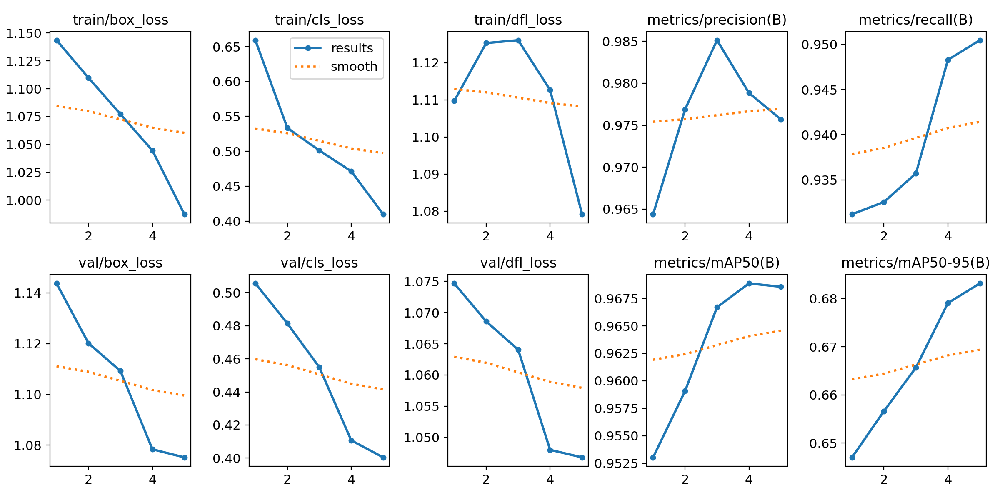

In [6]:
free_mem()
best = '/content/runs/license_plate/weights/best.pt'
model = YOLO(best)
metrics = model.val(data=str(yaml_path), device=0)
print(f"mAP@50: {metrics.box.map50:.3f} | mAP@50-95: {metrics.box.map:.3f}")

from IPython.display import Image as IPImage, display
display(IPImage('/content/runs/license_plate/results.png'))

## Add OCR to read the plate text

In [7]:
import easyocr
import cv2
import numpy as np
import re

reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())

def read_plate_text(crop):

    if crop.size == 0:
        return ""
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    results = reader.readtext(gray, detail=1)
    if not results:
        return ""

    best = max(results, key=lambda r: r[2])
    text = re.sub(r'[^A-Za-z0-9]', '', best[1]).upper()
    return text

mem_check("after OCR load")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete[after OCR load] RAM: 4.57/13.61 GB  | GPU: 0.36/15.64 GB


## Run on a video

In [8]:
from google.colab import files
import os, cv2
from collections import Counter, defaultdict

up = files.upload()
video_path = '/content/' + list(up.keys())[0]
os.rename(list(up.keys())[0], video_path)

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS) or 25
w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

os.makedirs('/content/output', exist_ok=True)
out_path = '/content/output/result_raw.mp4'
writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))


plate_text_history = defaultdict(lambda: Counter())
OCR_EVERY_N_FRAMES = 3

frame_idx = 0
for r in model.track(
        source=video_path, stream=True, conf=0.35, iou=0.5, imgsz=640,
        persist=True, tracker='bytetrack.yaml', verbose=False):
    frame = r.orig_img
    boxes = r.boxes
    if boxes is not None and boxes.id is not None:
        for box, track_id, conf in zip(boxes.xyxy.cpu().numpy(), boxes.id.int().tolist(), boxes.conf.cpu().numpy()):
            x1, y1, x2, y2 = map(int, box)
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)

            if frame_idx % OCR_EVERY_N_FRAMES == 0:
                crop = frame[y1:y2, x1:x2]
                text = read_plate_text(crop)
                if text:
                    plate_text_history[track_id][text] += 1

            display_text = plate_text_history[track_id].most_common(1)[0][0] if plate_text_history[track_id] else "..."
            label = f"{display_text} ({conf:.2f})"

            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
            cv2.rectangle(frame, (x1, y1 - th - 8), (x1 + tw + 4, y1), (0, 255, 0), -1)
            cv2.putText(frame, label, (x1 + 2, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

    writer.write(frame)
    frame_idx += 1
    if frame_idx % 100 == 0:
        mem_check(f"frame {frame_idx}")

writer.release()
free_mem()
print(f"Done. {frame_idx} frames written to {out_path}")
print("Recognized plates:", {tid: c.most_common(1)[0][0] for tid, c in plate_text_history.items()})

Saving 16503054_1920_1080_25fps.mp4 to 16503054_1920_1080_25fps.mp4
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 313ms
Prepared 1 package in 79ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

[frame 100] RAM: 4.66/13.61 GB  | GPU: 0.41/15.64 GB
[frame 200] RAM: 4.66/13.61 GB  | GPU: 0.41/15.64 GB
[frame 300] RAM: 4.66/13.61 GB  | GPU: 0.41/15.64 GB
[frame 400] RAM: 4.66/13.61 GB  | GPU: 0.41/15.64 GB
Done. 476 frames written to /content/output/result_raw.mp4


IndexError: list index out of range

In [9]:
print("Recognized plates:", {tid: c.most_common(1)[0][0] for tid, c in plate_text_history.items() if c})

Recognized plates: {1: 'KUU475', 2: 'LKZ787', 5: '0JG', 7: 'GU', 11: 'UPP425', 15: '964', 17: 'KN', 22: '104915', 24: 'JDB434'}


#Re-encode to H.264 mp4

In [10]:
import base64
from IPython.display import HTML, display

dst = '/content/output/result.mp4'
!ffmpeg -y -loglevel error -i "{out_path}" -vcodec libx264 -pix_fmt yuv420p "{dst}"

if os.path.getsize(dst) > 25e6:
    print("Video is large - skipping inline preview. Download it instead:", dst)
else:
    data = base64.b64encode(open(dst, 'rb').read()).decode()
    display(HTML(f'<video width=720 controls><source src="data:video/mp4;base64,{data}" type="video/mp4"></video>'))

# Download output and trained weights

In [13]:
files.download('/content/output/result.mp4')
files.download('/content/runs/license_plate/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>